1. 两幅 64×64 图像的直方图比较与模板滤波后比较（0 填充）
2. 灰度图加噪（椒盐/高斯/斑点）与滤波对比（中值/均值/给定模板）
3. Sobel 两个方向算子的响应比较
4. 隐形眼镜边缘提取（基于 `Fig0342(a)(contact_lens_original).tif`）

In [21]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt


def find_project_root() -> Path:
    """向上查找包含 Experiment_GUET 的目录，保证在不同 cwd 下都能定位到项目根。"""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'Experiment_GUET').exists():
            return p
    raise FileNotFoundError("未找到包含 'Experiment_GUET' 的项目根目录，请检查当前工作目录")


PROJECT_ROOT = find_project_root()
PIC_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'pic'
SRC_IMAGE_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'src' / 'class_img'


def read_gray(path: Path):
    """读取灰度图；若路径错误，抛出清晰异常，避免后续 NoneType 报错。"""
    if not path.exists():
        raise FileNotFoundError(f"图像不存在: {path}")
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"OpenCV 无法读取图像: {path}")
    return img


def show_image(ax, img, title):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')


def compute_pdf(img, level=256):
    # Align with Grayscale_transformation.ipynb: normalized histogram (PDF)
    counts = np.bincount(img.ravel(), minlength=level).astype(np.float64)
    return counts / img.size


def show_hist(ax, img, title):
    pdf = compute_pdf(img)
    ax.bar(range(256), pdf, width=1.0)
    ax.set_xlim(0, 255)
    ax.set_title(title)
    ax.set_xlabel('Gray Level')
    ax.set_ylabel('PDF')

def read(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return img

## 实验1：两幅 64×64 图的直方图与滤波后直方图比较

滤波前直方图是否完全一致: True
滤波后直方图是否完全一致: False


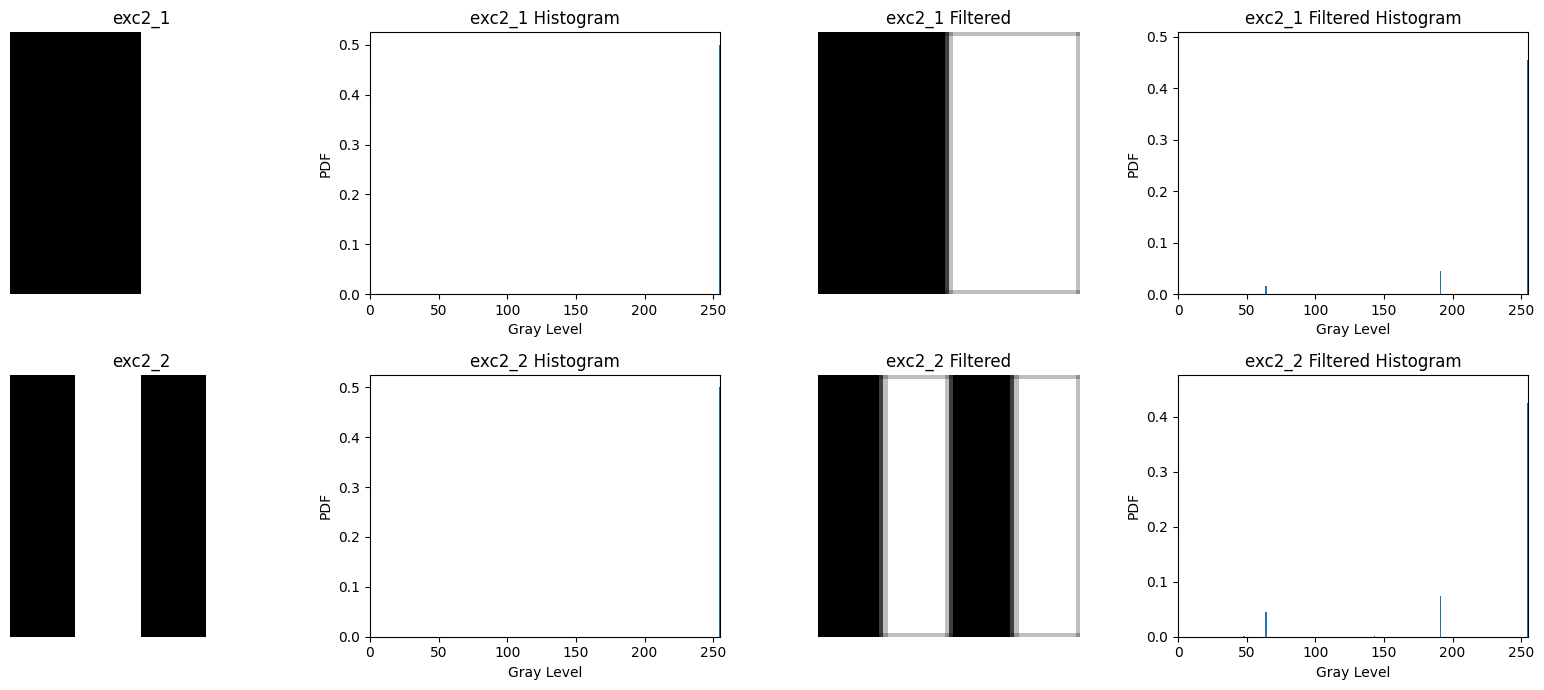

In [22]:
W = np.array([[1, 2, 1],
              [2, 4, 2],
              [1, 2, 1]], dtype=np.float32) / 16.0


def build_fallback_exc2_images(size=64):
    # 依据题图风格构造两幅 64x64 二值图：黑白面积相同但空间分布不同
    img1 = np.full((size, size), 255, dtype=np.uint8)
    img1[:, 16:48] = 0

    img2 = np.full((size, size), 255, dtype=np.uint8)
    img2[:, 8:24] = 0
    img2[:, 40:56] = 0
    return img1, img2


exc2_1 = read('/home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/src/class_img/ex2_1.png')
exc2_2 = read('/home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/src/class_img/ex2_2.png')

# 0 填充卷积
f1 = cv2.filter2D(exc2_1, -1, W, borderType=cv2.BORDER_CONSTANT)
f2 = cv2.filter2D(exc2_2, -1, W, borderType=cv2.BORDER_CONSTANT)


# 判断之前直方图是否一致
hist_equal_before = np.array_equal(
    cv2.calcHist([exc2_1], [0], None, [256], [0, 256]).ravel(),
    cv2.calcHist([exc2_2], [0], None, [256], [0, 256]).ravel(),
)


# 判断之后直方图是否一致
hist_equal_after = np.array_equal(
    cv2.calcHist([f1], [0], None, [256], [0, 256]).ravel(),
    cv2.calcHist([f2], [0], None, [256], [0, 256]).ravel(),
)

print(f'滤波前直方图是否完全一致: {hist_equal_before}')
print(f'滤波后直方图是否完全一致: {hist_equal_after}')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
show_image(axes[0, 0], exc2_1, 'exc2_1')
show_hist(axes[0, 1], exc2_1, 'exc2_1 Histogram')
show_image(axes[0, 2], f1, 'exc2_1 Filtered')
show_hist(axes[0, 3], f1, 'exc2_1 Filtered Histogram')

show_image(axes[1, 0], exc2_2, 'exc2_2')
show_hist(axes[1, 1], exc2_2, 'exc2_2 Histogram')
show_image(axes[1, 2], f2, 'exc2_2 Filtered')
show_hist(axes[1, 3], f2, 'exc2_2 Filtered Histogram')

plt.tight_layout()
plt.show()

# 2300350128叶西佳

## 实验2：灰度图加噪 + 中值/均值/给定模板滤波对比

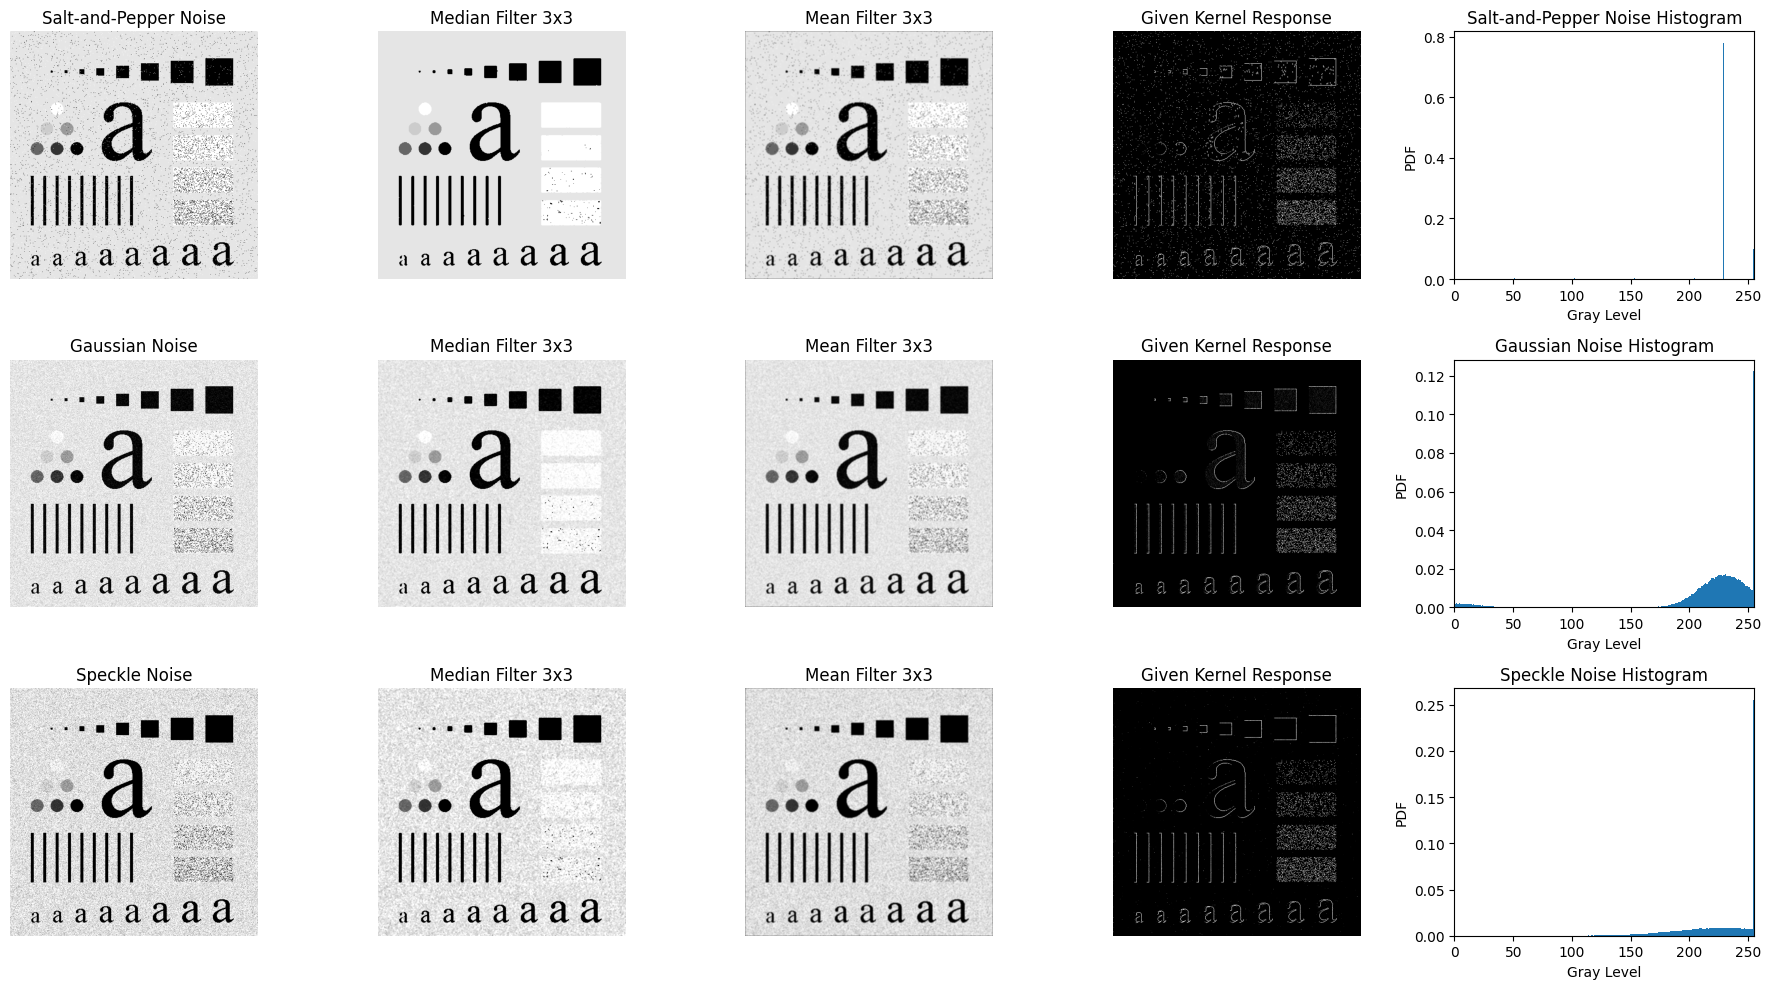

In [23]:
def add_salt_pepper_noise(img, amount=0.03, salt_vs_pepper=0.5):
    noisy = img.copy()
    total = img.size
    num_salt = int(total * amount * salt_vs_pepper)
    num_pepper = int(total * amount * (1 - salt_vs_pepper))

    ys = np.random.randint(0, img.shape[0], num_salt)
    xs = np.random.randint(0, img.shape[1], num_salt)
    noisy[ys, xs] = 255

    ys = np.random.randint(0, img.shape[0], num_pepper)
    xs = np.random.randint(0, img.shape[1], num_pepper)
    noisy[ys, xs] = 0
    return noisy


def add_gaussian_noise(img, mean=0.0, sigma=20.0):
    noise = np.random.normal(mean, sigma, img.shape)
    out = img.astype(np.float32) + noise
    return np.clip(out, 0, 255).astype(np.uint8)


def add_speckle_noise(img, sigma=0.2):
    # 斑点噪声：I + I*n
    n = np.random.normal(0.0, sigma, img.shape)
    out = img.astype(np.float32) + img.astype(np.float32) * n
    return np.clip(out, 0, 255).astype(np.uint8)


base_img = read_gray(SRC_IMAGE_DIR / 'Fig0333(a)(test_pattern_blurring_orig).png')

sp_img = add_salt_pepper_noise(base_img, amount=0.03)
gauss_img = add_gaussian_noise(base_img, sigma=20)
speckle_img = add_speckle_noise(base_img, sigma=0.18)

avg_kernel = np.ones((3, 3), dtype=np.float32) / 9.0
lap_kernel = np.array([[0, 1, 0],
                       [-1, -4, 1],
                       [0, 1, 0]], dtype=np.float32)

noisy_set = {
    'Salt-and-Pepper Noise': sp_img,
    'Gaussian Noise': gauss_img,
    'Speckle Noise': speckle_img,
}

fig, axes = plt.subplots(len(noisy_set), 5, figsize=(18, 10))
for r, (name, noisy) in enumerate(noisy_set.items()):
    median = cv2.medianBlur(noisy, 3) # 取蒙版中的中间值作为中心的像素值
    mean_blur = cv2.filter2D(noisy, -1, avg_kernel, borderType=cv2.BORDER_CONSTANT)
    lap_resp = cv2.filter2D(noisy.astype(np.float32), -1, lap_kernel, borderType=cv2.BORDER_CONSTANT)# 先转化为float，便于计算，因为会有正负值
    lap_show = np.clip(lap_resp, 0, 255).astype(np.uint8)# 先取绝对值再转成 uint8（0~255），得到适合 imshow 显示的结果图 lap_show
    show_image(axes[r, 0], noisy, f'{name}')
    show_image(axes[r, 1], median, 'Median Filter 3x3')
    show_image(axes[r, 2], mean_blur, 'Mean Filter 3x3')
    show_image(axes[r, 3], lap_show, 'Given Kernel Response')
    show_hist(axes[r, 4], noisy, f'{name} Histogram')

plt.tight_layout()
plt.show()

# 2300350128 叶西佳

## 实验3：Sobel 两个方向算子响应比较

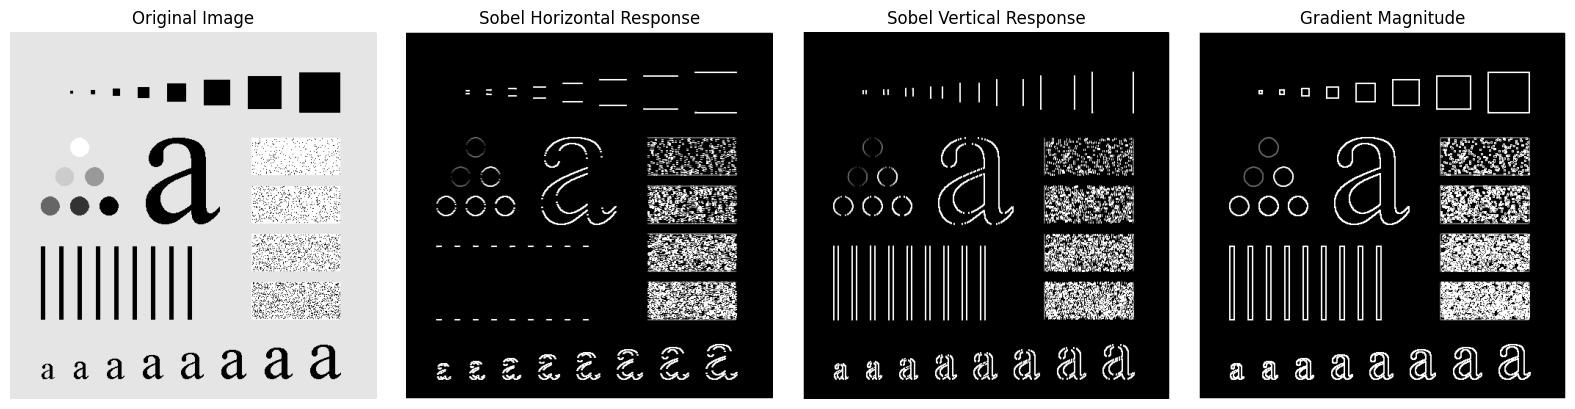

结论提示：
- [-1 -2 -1; 0 0 0; 1 2 1] 更强调水平边缘（灰度沿竖直方向变化）。
- [-1 0 1; -2 0 2; -1 0 1] 更强调垂直边缘（灰度沿水平方向变化）。


In [24]:
sobel_h = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

sobel_v = np.array([[-1,  0,  1],
                    [-2,  0,  2],
                    [-1,  0,  1]], dtype=np.float32)

img_sobel = read_gray(SRC_IMAGE_DIR / 'Fig0333(a)(test_pattern_blurring_orig).png')
if img_sobel is None:
    img_sobel = base_img

resp_h = cv2.filter2D(img_sobel.astype(np.float32), -1, sobel_h, borderType=cv2.BORDER_CONSTANT)
resp_v = cv2.filter2D(img_sobel.astype(np.float32), -1, sobel_v, borderType=cv2.BORDER_CONSTANT)
mag = cv2.magnitude(resp_h, resp_v)

resp_h_show = cv2.convertScaleAbs(resp_h)
resp_v_show = cv2.convertScaleAbs(resp_v)
mag_show = cv2.convertScaleAbs(mag)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
show_image(axes[0], img_sobel, 'Original Image')
show_image(axes[1], resp_h_show, 'Sobel Horizontal Response')
show_image(axes[2], resp_v_show, 'Sobel Vertical Response')
show_image(axes[3], mag_show, 'Gradient Magnitude')
plt.tight_layout()
plt.show()

print('结论提示：')
print('- [-1 -2 -1; 0 0 0; 1 2 1] 更强调水平边缘（灰度沿竖直方向变化）。')
print('- [-1 0 1; -2 0 2; -1 0 1] 更强调垂直边缘（灰度沿水平方向变化）。')

# 2300350128 叶西佳

## 实验4：隐形眼镜边界提取

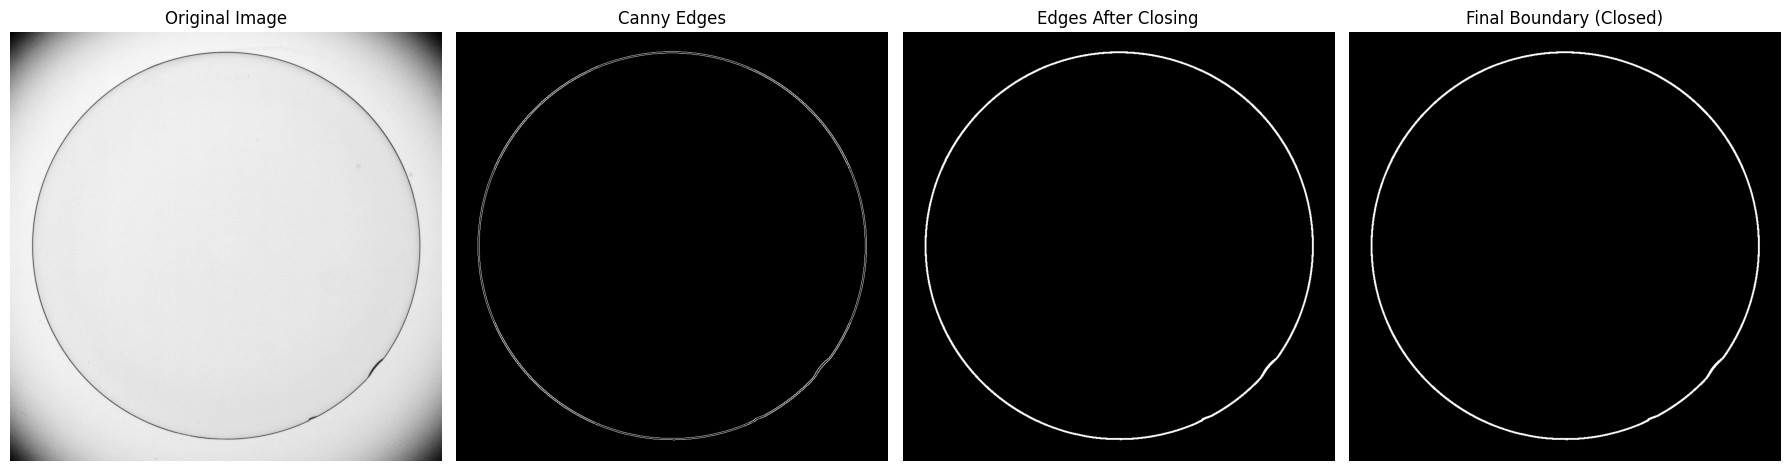

结果已保存到: /home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/src/class_img/exp_content_results


In [27]:
lens = read_gray(PIC_DIR / 'Fig0342(a)(contact_lens_original).tif')
if lens is None:
    raise FileNotFoundError('未找到 Fig0342(a)(contact_lens_original).tif')

# 兼容灰度图/彩色图输入
if lens.ndim == 3:
    lens_gray = cv2.cvtColor(lens, cv2.COLOR_BGR2GRAY)
    result_overlay = lens.copy()
else:
    lens_gray = lens
    result_overlay = cv2.cvtColor(lens_gray, cv2.COLOR_GRAY2BGR)

# 预处理：轻度平滑，降低噪声对边缘检测的影响
lens_blur = cv2.GaussianBlur(lens_gray, (5, 5), 1.2)

# Canny 提取边缘
edges = cv2.Canny(lens_blur, 35, 90)

# 用形态学闭运算增强边缘连续性
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

# 简化：闭运算后直接作为最终边界
boundary_only = edges_closed.copy()

# 直接叠加闭运算结果到原图（白色边缘）
result_overlay = cv2.cvtColor(lens_gray, cv2.COLOR_GRAY2BGR)
result_overlay[boundary_only > 0] = (255, 255, 255)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
show_image(axes[0], lens_gray, 'Original Image')
show_image(axes[1], edges, 'Canny Edges')
show_image(axes[2], edges_closed, 'Edges After Closing')
show_image(axes[3], boundary_only, 'Final Boundary (Closed)')
plt.tight_layout()
plt.show()

# 可选：保存结果
out_dir = SRC_IMAGE_DIR / 'exp_content_results'
out_dir.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(out_dir / 'lens_boundary_only.png'), boundary_only)
cv2.imwrite(str(out_dir / 'lens_overlay.png'), result_overlay)
print(f'结果已保存到: {out_dir}')

# 2300350128 叶西佳